In [4]:
import numpy as np
import pandas as pd

# Generate data for NARX 1 & NARX 2

## NARX 1

In [5]:
# NARX 1

def sim_narx1(n, sigmau, sigmaw, seed):
    y= np.zeros((n, 2))
    np.random.seed(seed)
    u = np.random.normal(0, sigmau, n)
    w = np.random.normal(0, sigmaw, (n, 2))

    y[1, :] = w[1, :] # k = 0

    for k in range(1, n - 1):
        y[k + 1, 0] = 0.5 * y[k - 1, 1] + np.sin(y[k, 1]) + 0.3 * u[k - 1] + w[k + 1, 0]

        y[k + 1, 1] = 0.5 * y[k - 1, 0] + np.sin(y[k, 0]) + 0.2 * u[k] + w[k + 1, 1]
    
    return u, y

#NARX 2
def sim_narx2(n, sigmau, sigmaw, seed):
    np.random.seed(seed)
    u = np.random.normal(0, sigmau, (n, 2))
    y = np.zeros((n, 2))
    w = np.random.normal(0, sigmaw, (n, 2))

    #y[0:3, :] = 0 #set initial conditions to 0 to avoid any instabily from the start
    y[0:3] = np.random.normal(0, 0.5, (3,2))
    
    for k in range(2, n - 1):
        top1 = (y[k, 0] * y[k - 1, 0] * y[k - 2, 0] * (y[k - 2, 0] - 1) * u[k - 1, 1]) + u[k, 1]
        bot1 = 1 + (y[k - 1, 1]**2) + (y[k - 2, 1]**2)
        y[k + 1, 0] = (top1 / bot1) + w[k + 1, 0]

        top2 = (y[k, 1] * y[k - 1, 1] * y[k - 2, 1] * (y[k - 2, 1] - 1) * u[k - 1, 0]) + u[k, 0]
        bot2 = 1 + (y[k - 1, 0]**2) + (y[k - 2, 0]**2)
        y[k + 1, 1] = (top2 / bot2) + w[k + 1, 1]
        
    return u, y

# Pre-processing

In [6]:
u_narx1, y_narx1 = sim_narx1(1000, 1, 0.1, 42) #sigmau needs to be at least =1 bc if it's smaller y1 & y2 are too correlated
u_narx2, y_narx2 = sim_narx2(1000, 0.0001, 0.00001, 42) #sigmau & sigmaw need to be small, otherwise y explodes

In [7]:
#turn generated data into dataframe so it's easier to use later on
import pandas as pd

def narx1_to_dataframe(u, y):
    narx1 = pd.DataFrame({
        "u": u_narx1,
        "y1": y_narx1[:, 0],
        "y2": y_narx1[:, 1]
    })
    return narx1

def narx2_to_dataframe(u, y):
    narx2 = pd.DataFrame({
        "u1": u_narx2[:, 0],
        "u2": u_narx2[:, 1],
        "y1": y_narx2[:, 0],
        "y2": y_narx2[:, 1],
    })
    return narx2

narx1 = narx1_to_dataframe(u_narx1, y_narx1)
narx2 = narx2_to_dataframe(u_narx2, y_narx2)

## MC to observe y (NARX 2)

# Parameters selection approach

## NARX1

In [5]:
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import pacf
from statsmodels.graphics.tsaplots import plot_pacf

#use PACF to determine na
#downside of PACF is that it won't be able to see the interaction between y1 & y2 BUT will give us idea of candidates to use for na in our grid search

pacf_y1 = pacf(narx1["y1"], nlags=10)
pacf_y2 = pacf(narx1["y2"], nlags=10)

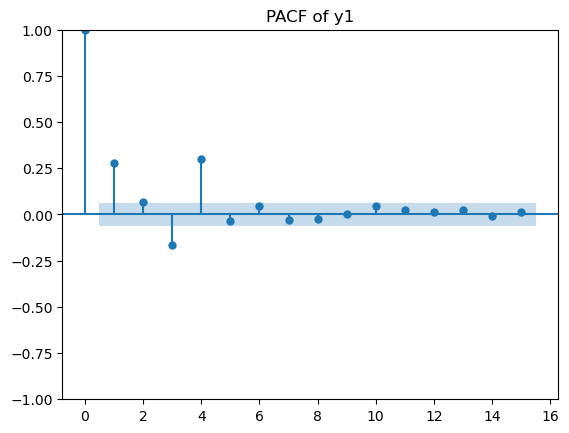

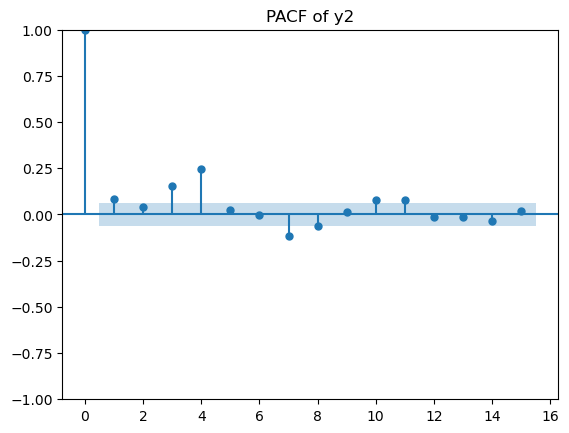

In [82]:
plot_pacf(narx1["y1"], lags=15)
plt.title("PACF of y1")
plt.show()

plot_pacf(df["y2"], lags=15)
plt.title("PACF of y2")
plt.show()


#PACF of y1: ~lag 4 seems to be significant (2 is borderline, but still some influence)
#PACF of y2: ~lag 4 seems to be significant (1-2 are small though)
#our candidates for na (output lag) -> [1:4] but PACF only takes individual effect of y(i) on itself -> we need to see the effect of y1 on y2 and vice versa

In [12]:
"""
for u, we can't use PACF. Instead, we'll use cross-correlation -> will give us candidates to use in grid seach
we create our own ccf function because the statsmodels.ccf function calculates the corr(x(k−ℓ),y(k)) 
but the one we need is corr(x(k−ℓ),y(k+1)). statsmodels.ccf doesn't handle shifting the data
"""

def compute_ccf(u, y, max_lag):
    ccf_values = []
    
    #we shift y by one so we look at y(k+1) and u(k)
    u = u[:-1]
    y = y[1:]
    
    for lag in range(max_lag + 1):
        if lag == 0:
            corr = np.corrcoef(u, y)[0,1]
        else:
            corr = np.corrcoef(u[:-lag], y[lag:])[0,1]
        
        ccf_values.append(corr)
    
    return np.array(ccf_values)

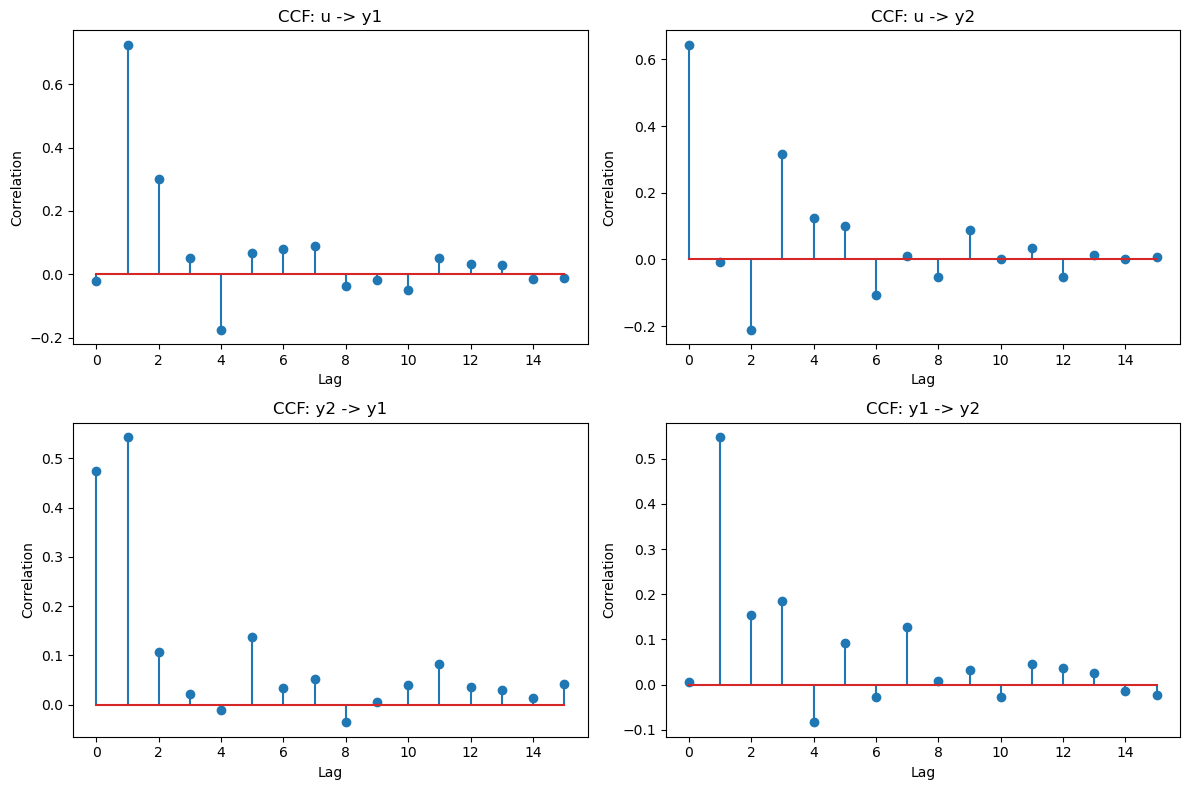

'\nccf will help us choose d (delay), na (output lag) and nb (input lag)\nfirst lag where correlation becomes significative -> delay\n\nu -> y1 -> 1st significant effect at lag 1 (with secondary effect at lag 2)--> nb_y1 = [1, 2]\nu -> y2 -> first significant effect at lag 0 (dominant) --> nb_y2 = [0, 2, 3]\n --> nb ~ [1, 2, 3]\n\n-----------------\ny2 -> y1 -> significant effects at lags 0 and 1 --> na_y1 ~ = [0, 1]\ny1 -> y2 -> significant effects at lag 1 --> na_y2 ~ = [1, 2, 3]\n--> delay = d ~ [0,1], na ~ = [1, 2, 3, 4] (take 4 to nt be too strict)\n'

In [83]:
u  = narx1["u"].values
y1 = narx1["y1"].values
y2 = narx1["y2"].values

ccf_u_y1 = compute_ccf(u, y1, max_lag=15)
ccf_u_y2 = compute_ccf(u, y2, max_lag=15)
ccf_y2_y1 = compute_ccf(y2, y1, max_lag=15)
ccf_y1_y2 = compute_ccf(y1, y2, max_lag=15)

import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# u → y1
axes[0, 0].stem(range(len(ccf_u_y1)), ccf_u_y1)
axes[0, 0].set_title("CCF: u -> y1")
axes[0, 0].set_xlabel("Lag")
axes[0, 0].set_ylabel("Correlation")

# u → y2
axes[0, 1].stem(range(len(ccf_u_y2)), ccf_u_y2)
axes[0, 1].set_title("CCF: u -> y2")
axes[0, 1].set_xlabel("Lag")
axes[0, 1].set_ylabel("Correlation")

# y2 → y1
axes[1, 0].stem(range(len(ccf_y2_y1)), ccf_y2_y1)
axes[1, 0].set_title("CCF: y2 -> y1")
axes[1, 0].set_xlabel("Lag")
axes[1, 0].set_ylabel("Correlation")

# y1 → y2
axes[1, 1].stem(range(len(ccf_y1_y2)), ccf_y1_y2)
axes[1, 1].set_title("CCF: y1 -> y2")
axes[1, 1].set_xlabel("Lag")
axes[1, 1].set_ylabel("Correlation")

plt.tight_layout()
plt.show()


"""
ccf will help us choose d (delay), na (output lag) and nb (input lag)
first lag where correlation becomes significative -> delay

u -> y1 -> 1st significant effect at lag 1 (with secondary effect at lag 2)--> nb_y1 = [1, 2]
u -> y2 -> first significant effect at lag 0 (dominant) --> nb_y2 = [0, 2, 3]
 --> nb ~ [1, 2, 3]

-----------------
y2 -> y1 -> significant effects at lags 0 and 1 --> na_y1 ~ = [0, 1]
y1 -> y2 -> significant effects at lag 1 --> na_y2 ~ = [1, 2, 3]
--> delay = d ~ [0,1], na ~ = [1, 2, 3, 4] (take 4 to nt be too strict)
"""

#### Grid search 

In [14]:
na_grid = [1, 2, 3, 4]
nb_grid = [1, 2, 3]
d_grid  = [0, 1]

# NARX2

#### STEP 1: create lagged dataset + targets and features

In [100]:
import pandas as pd

def lagged_dataset(u1, u2, y1, y2, max_lag=2):
    
    data = pd.DataFrame({
    "u1": u1,
    "u2": u2,
    "y1": y1,
    "y2": y2
    })

    lagged_data = pd.DataFrame()
    
    for var in ["u1", "u2", "y1", "y2"]:
        for lag in range(1, max_lag + 1):
            lagged_data[f"{var}_lag{lag}"] = data[var].shift(lag)

    # Targets
    lagged_data["y1_target"] = data["y1"].shift(-1)
    lagged_data["y2_target"] = data["y2"].shift(-1)

    # Drop NaNs
    lagged_data = lagged_data.dropna().reset_index(drop=True)

    # Séparation
    X = lagged_data.drop(columns=["y1_target", "y2_target"])
    y1_target = lagged_data["y1_target"]
    y2_target = lagged_data["y2_target"]

    return X, y1_target, y2_target

In [101]:
u1_narx2 = narx2["u1"]
u2_narx2 = narx2["u2"]
y1_narx2 = narx2["y1"]
y2_narx2 = narx2["y2"]

X, y1_target, y2_target = lagged_dataset(u1_narx2, u2_narx2, y1_narx2, y2_narx2, max_lag=3)

#### STEP 2: polynomial features (degree = 2)

In [102]:
from sklearn.preprocessing import PolynomialFeatures

# degree = 2 (to start)
poly = PolynomialFeatures(degree=3, include_bias=False)

X_poly = poly.fit_transform(X)

feature_names = poly.get_feature_names_out(X.columns)

print("Original shape:", X.shape, ", nb features:", X.shape[1])
print("Polynomial shape:", X_poly.shape, ", nb features:", X_poly.shape[1])

Original shape: (996, 12) , nb features: 12
Polynomial shape: (996, 454) , nb features: 454


#### STEP 3: mutual information on the features (feature selection #1)

In [103]:
from sklearn.feature_selection import mutual_info_regression

mi_y1 = mutual_info_regression(X_poly, y1_target)
mi_y2 = mutual_info_regression(X_poly, y2_target)

In [104]:
import numpy as np

indexes_y1 = np.argsort(mi_y1)[::-1]
mi_y1_sorted = mi_y1[indexes_y1]

indexes_y2 = np.argsort(mi_y2)[::-1]
mi_y2_sorted = mi_y2[indexes_y2]

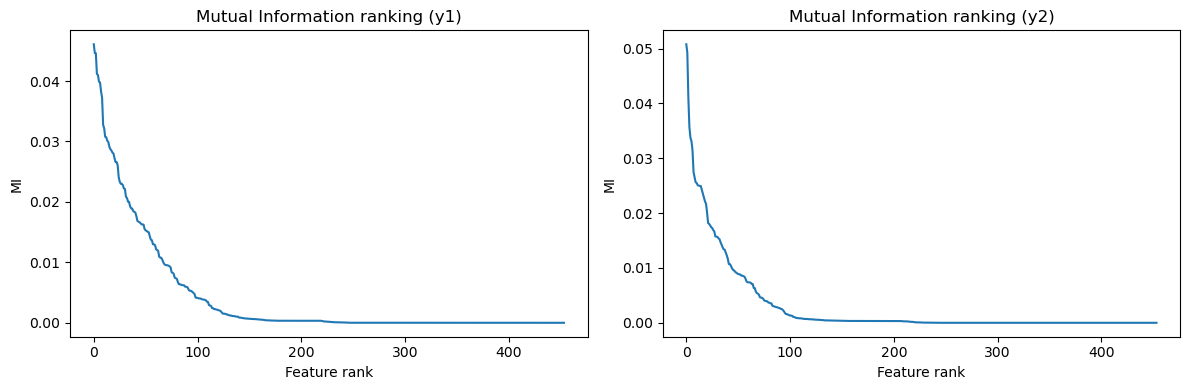

"\nwe see that a lot of features are ~0, but it's hard to tell exactly how many to take by looking at the graph, so we'll use cumulative MI. \n--> We'll keep the features that gives us 90% of the information\n"

In [105]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 2, figsize=(12, 4))

# Graphique y1
axs[0].plot(mi_y1_sorted)
axs[0].set_title("Mutual Information ranking (y1)")
axs[0].set_xlabel("Feature rank")
axs[0].set_ylabel("MI")

# Graphique y2
axs[1].plot(mi_y2_sorted)
axs[1].set_title("Mutual Information ranking (y2)")
axs[1].set_xlabel("Feature rank")
axs[1].set_ylabel("MI")

plt.tight_layout()
plt.show()

"""
we see that a lot of features are ~0, but it's hard to tell exactly how many to take by looking at the graph, so we'll use cumulative MI. 
--> We'll keep the features that gives us 90% of the information
"""

In [106]:
def find_k_cumulative(mi_sorted, ratio=0.9):
    cum = np.cumsum(mi_sorted)
    cum /= cum[-1]
    return np.where(cum >= ratio)[0][0]

k_y1 = find_k_cumulative(mi_y1_sorted)
k_y2 = find_k_cumulative(mi_y2_sorted)

print("K_y1 (cumulative):", k_y1)
print("K_y2 (cumulative):", k_y2)

#save the features' indexes and name for later use
selected_idx_y1 = indexes_y1[:88]
selected_idx_y2 = indexes_y2[:73]

feature_names = poly.get_feature_names_out()

selected_names_y1 = feature_names[selected_idx_y1]
selected_names_y2 = feature_names[selected_idx_y2]

K_y1 (cumulative): 88
K_y2 (cumulative): 73


#### STEP 4: wrapper method on selected features 

In [107]:
#features selected by MI
X_y1 = X_poly[:, selected_idx_y1]
X_y2 = X_poly[:, selected_idx_y2]

# Targets
y1 = y1_target
y2 = y2_target


 13%|█████▊                                      | 2/15 [00:00<00:02,  5.38it/s]

Step 1: added feature 2, NMSE=1.004049
Step 2: added feature 45, NMSE=1.003628


 27%|███████████▋                                | 4/15 [00:00<00:01,  5.84it/s]

Step 3: added feature 33, NMSE=1.003255
Step 4: added feature 38, NMSE=1.002967


 40%|█████████████████▌                          | 6/15 [00:01<00:01,  5.82it/s]

...

Step 13: added feature 54, NMSE=1.007412


 93%|████████████████████████████████████████▏  | 14/15 [00:02<00:00,  5.12it/s]

Step 14: added feature 29, NMSE=1.008441


100%|███████████████████████████████████████████| 15/15 [00:02<00:00,  5.38it/s]

Step 15: added feature 53, NMSE=1.010445

Selected features (y1):
['u2_lag3^2 y1_lag1' 'u2_lag2 u2_lag3 y1_lag3' 'u1_lag3 u2_lag1 y1_lag3'
 'u1_lag2 u1_lag3 u2_lag3' 'u1_lag3 u2_lag3^2' 'u1_lag1 u2_lag1'
 'u1_lag2 u2_lag2 u2_lag3' 'u2_lag3 y1_lag3' 'u1_lag1 u2_lag2 y1_lag3'
 'u1_lag1 u1_lag2' 'u2_lag1' 'u1_lag1' 'u1_lag3 u2_lag2 y2_lag2'
 'u1_lag2 u1_lag3' 'u1_lag3']


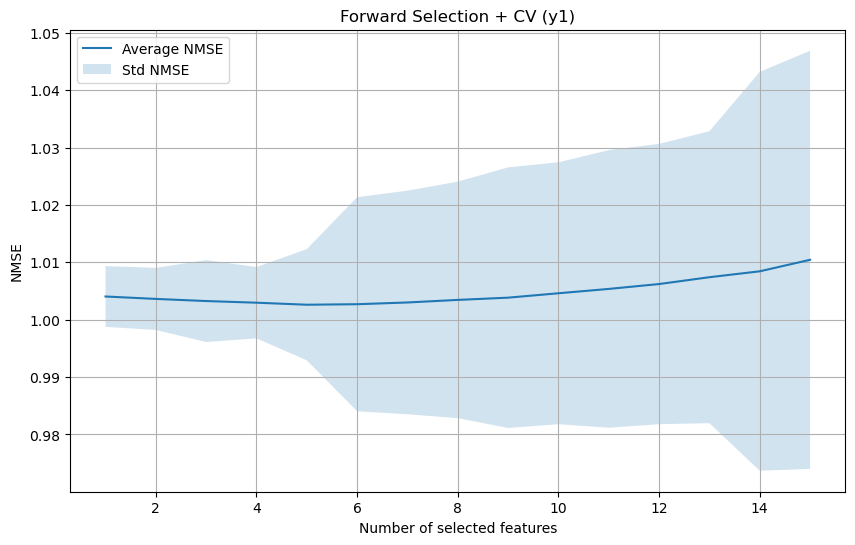

In [108]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import TimeSeriesSplit
from tqdm import tqdm

X = X_y1          # features after MI
Y = y1            # target
n = X.shape[1]
max_features = 15  # max features to select

# NMSE
def nmse(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2) / np.var(y_true)

# CROSS VALIDATION (TIME SERIES)
kf = TimeSeriesSplit(n_splits=5)


# FORWARD SELECTION
selected = []
CV_errs = []
std_errs = []

for round_i in tqdm(range(max_features)):
    candidates = list(set(range(n)) - set(selected))
    
    CV_err_temp = []
    std_temp = []
    
    for c in candidates:
        features_to_include = selected + [c]
        fold_errors = []
        
        for train_index, test_index in kf.split(X):
            X_tr = X[train_index][:, features_to_include]
            X_ts = X[test_index][:, features_to_include]
            
            Y_tr = Y[train_index]
            Y_ts = Y[test_index]
            
            model = LinearRegression()
            model.fit(X_tr, Y_tr)
            
            Y_hat_ts = model.predict(X_ts)
            fold_errors.append(nmse(Y_ts, Y_hat_ts))
        
        CV_err_temp.append(np.mean(fold_errors))
        std_temp.append(np.std(fold_errors))
    
    best_idx = np.argmin(CV_err_temp)
    best_candidate = candidates[best_idx]
    
    selected.append(best_candidate)
    
    CV_errs.append(CV_err_temp[best_idx])
    std_errs.append(std_temp[best_idx])
    
    print(f"Step {round_i+1}: added feature {best_candidate}, NMSE={CV_err_temp[best_idx]:.6f}")


# FINAL FEATURES 
selected_features_names = selected_names_y1[selected]

print("\nSelected features (y1):")
print(selected_features_names)


# PLOT
x = list(range(1, len(CV_errs)+1))
errors = np.array(CV_errs)
stds = np.array(std_errs)

plt.figure(figsize=(10, 6))
plt.plot(x, errors, label="Average NMSE")
plt.fill_between(x, errors - stds, errors + stds, alpha=0.2, label="Std NMSE")
plt.xlabel("Number of selected features")
plt.ylabel("NMSE")
plt.title("Forward Selection + CV (y1)")
plt.legend()
plt.grid(True)
plt.show()

In [109]:
final_k = 5
final_idx = selected[:final_k]
final_features = selected_names_y1[final_idx]

print(final_features)

['u2_lag3^2 y1_lag1' 'u2_lag2 u2_lag3 y1_lag3' 'u1_lag3 u2_lag1 y1_lag3'
 'u1_lag2 u1_lag3 u2_lag3' 'u1_lag3 u2_lag3^2']


In [113]:
X = X_y2
Y = y2
selected_names_y = selected_names_y2

 13%|█████▊                                      | 2/15 [00:00<00:01,  6.66it/s]

Step 1: added feature 9, NMSE=0.996956
Step 2: added feature 3, NMSE=0.994205


 27%|███████████▋                                | 4/15 [00:00<00:01,  7.15it/s]

Step 3: added feature 11, NMSE=0.993956
Step 4: added feature 21, NMSE=0.993358


 40%|█████████████████▌                          | 6/15 [00:00<00:01,  7.22it/s]

...

Step 11: added feature 29, NMSE=0.995985
Step 12: added feature 36, NMSE=0.997018


 93%|████████████████████████████████████████▏  | 14/15 [00:02<00:00,  6.62it/s]

Step 13: added feature 6, NMSE=0.998654
Step 14: added feature 12, NMSE=1.000460


100%|███████████████████████████████████████████| 15/15 [00:02<00:00,  6.89it/s]


Step 15: added feature 65, NMSE=1.002472

Selected features (y2):
['u2_lag1^2 y2_lag2' 'u2_lag1 u2_lag2 y2_lag1' 'u1_lag3 y2_lag2'
 'u1_lag2^2 y1_lag1' 'u1_lag2 u2_lag2 y2_lag1' 'u1_lag3 u2_lag2 y1_lag3'
 'u1_lag1 u1_lag2^2' 'u1_lag1 y1_lag3' 'u1_lag2 u2_lag2 u2_lag3'
 'u2_lag3 y2_lag1' 'u1_lag2 u1_lag3' 'u2_lag1 y2_lag1' 'u2_lag1'
 'u1_lag1 u2_lag1' 'u2_lag1 y1_lag1']


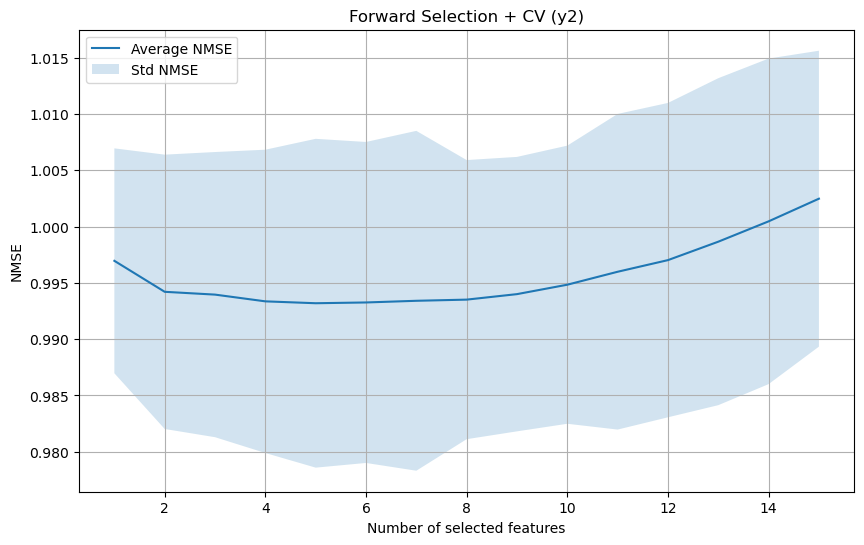

In [111]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import TimeSeriesSplit
from tqdm import tqdm


X = X_y2          # features after MI
Y = y2            # target
n = X.shape[1]
max_features = 15  # max features to select

# NMSE
def nmse(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2) / np.var(y_true)

# CROSS VALIDATION (TIME SERIES)
kf = TimeSeriesSplit(n_splits=5)


# FORWARD SELECTION

selected = []
CV_errs = []
std_errs = []

for round_i in tqdm(range(max_features)):
    candidates = list(set(range(n)) - set(selected))
    
    CV_err_temp = []
    std_temp = []
    
    for c in candidates:
        features_to_include = selected + [c]
        fold_errors = []
        
        for train_index, test_index in kf.split(X):
            X_tr = X[train_index][:, features_to_include]
            X_ts = X[test_index][:, features_to_include]
            
            Y_tr = Y[train_index]
            Y_ts = Y[test_index]
            
            model = LinearRegression()
            model.fit(X_tr, Y_tr)
            
            Y_hat_ts = model.predict(X_ts)
            fold_errors.append(nmse(Y_ts, Y_hat_ts))
        
        CV_err_temp.append(np.mean(fold_errors))
        std_temp.append(np.std(fold_errors))
    
    best_idx = np.argmin(CV_err_temp)
    best_candidate = candidates[best_idx]
    
    selected.append(best_candidate)
    
    CV_errs.append(CV_err_temp[best_idx])
    std_errs.append(std_temp[best_idx])
    
    print(f"Step {round_i+1}: added feature {best_candidate}, NMSE={CV_err_temp[best_idx]:.6f}")


# FINAL FEATURES 
selected_features_names = selected_names_y1[selected]

print("\nSelected features (y2):")
print(selected_features_names)


# PLOT
x = list(range(1, len(CV_errs)+1))
errors = np.array(CV_errs)
stds = np.array(std_errs)

plt.figure(figsize=(10, 6))
plt.plot(x, errors, label="Average NMSE")
plt.fill_between(x, errors - stds, errors + stds, alpha=0.2, label="Std NMSE")
plt.xlabel("Number of selected features")
plt.ylabel("NMSE")
plt.title("Forward Selection + CV (y2)")
plt.legend()
plt.grid(True)
plt.show()

In [98]:
final_k = 5
final_idx_y2 = selected[:final_k]
final_features_y2 = selected_names_y2[final_idx_y2]

print(final_features_y2)

['u1_lag1 u2_lag1 u2_lag3' 'u2_lag2' 'u1_lag3^2 y2_lag3'
 'u1_lag2 u1_lag3 y1_lag2' 'u1_lag1 u2_lag3 y1_lag3']


In [118]:
"""
For y1 :
  - Lags of y found : y1_lag1, y1_lag3
  - Lags of u found : u1_lag2, u1_lag3, u2_lag1, u2_lag2, u2_lag3 

For y2 :
  - Lags of y found : y2_lag3, y1_lag2, y1_lag3
  - Lags of u found : u1_lag1, u1_lag2, u1_lag3, u2_lag1, u2_lag2, u2_lag3 



# For y1:
best_params_y1 = grid_search_y1(
    d_range=[0, 1, 2],
    n_a_range=[1, 2, 3],
    n_b_range=[1, 2, 3]
)
# Résultat : d₁=0, n_a₁=2, n_b₁=1

# Pour y2:
best_params_y2 = grid_search_y2(
    d_range=[0, 1, 2],
    n_a_range=[1, 2, 3],
    n_b_range=[1, 2, 3]
)
"""

'\nFor y1 :\n  - Lags of y found : y1_lag1, y1_lag3\n  - Lags of u found : u1_lag2, u1_lag3, u2_lag1, u2_lag2, u2_lag3 \n\nFor y2 :\n  - Lags of y found : y2_lag3, y1_lag2, y1_lag3\n  - Lags of u found : u1_lag1, u1_lag2, u1_lag3, u2_lag1, u2_lag2, u2_lag3 \n\n\n\n# For y1:\nbest_params_y1 = grid_search_y1(\n    d_range=[0, 1, 2],\n    n_a_range=[1, 2, 3],\n    n_b_range=[1, 2, 3]\n)\n# Résultat : d₁=0, n_a₁=2, n_b₁=1\n\n# Pour y2:\nbest_params_y2 = grid_search_y2(\n    d_range=[0, 1, 2],\n    n_a_range=[1, 2, 3],\n    n_b_range=[1, 2, 3]\n)\n'